In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor


In [2]:
events = pd.read_csv("events.csv")

In [3]:
events["timestamp"] = pd.to_datetime(events["timestamp"])

 # 3. CREATE TARGET: purchase_time_hours

In [4]:
session_start = (
    events.groupby("session_id")["timestamp"]
    .min()
    .reset_index(name="session_start_time")
)

# Purchase time
purchase_time = (
    events[events["event_type"] == "purchase"]
    .groupby("session_id")["timestamp"]
    .min()
    .reset_index(name="purchase_time")
)

# Merge and compute target
session_time = session_start.merge(
    purchase_time,
    on="session_id",
    how="inner"
)

session_time["purchase_time_hours"] = (
    session_time["purchase_time"] - session_time["session_start_time"]
).dt.total_seconds() / 3600


# 4. FEATURE ENGINEERING (SESSION LEVEL)

In [5]:
event_counts = (
    events.groupby("session_id")
    .size()
    .reset_index(name="total_events")
)

# Add-to-cart events
add_to_cart_events = (
    events[events["event_type"] == "add_to_cart"]
    .groupby("session_id")
    .size()
    .reset_index(name="add_to_cart_events")
)

# Page views
page_view_events = (
    events[events["event_type"] == "page_view"]
    .groupby("session_id")
    .size()
    .reset_index(name="page_view_events")
)

# Total purchase amount
total_amount = (
    events[events["event_type"] == "purchase"]
    .groupby("session_id")["amount_usd"]
    .sum()
    .reset_index(name="total_amount_usd")
)


# 5. MERGE ALL FEATURES

In [6]:
session_features = session_time.merge(event_counts, on="session_id")
session_features = session_features.merge(add_to_cart_events, on="session_id", how="left")
session_features = session_features.merge(page_view_events, on="session_id", how="left")
session_features = session_features.merge(total_amount, on="session_id", how="left")

session_features.fillna(0, inplace=True)

# Save engineered dataset (IMPORTANT)
session_features.to_csv("session_features.csv", index=False)

# 6. FEATURE / TARGET SPLIT

In [7]:
X = session_features.drop(
    columns=["session_id", "session_start_time", "purchase_time", "purchase_time_hours"]
)
y = session_features["purchase_time_hours"]

# Log transform target
y_log = np.log1p(y)

# 7. TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)


# 8. BASELINE MODEL

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = np.expm1(lr.predict(X_test))
y_test_original = np.expm1(y_test)

print("\nBaseline Linear Regression")
print("MAE :", round(mean_absolute_error(y_test_original, y_pred_lr), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_original, y_pred_lr)), 3))
print("R²  :", round(r2_score(y_test_original, y_pred_lr), 3))



Baseline Linear Regression
MAE : 0.25
RMSE: 0.319
R²  : 0.73


# 9. XGBOOST MODEL

In [10]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = np.expm1(xgb.predict(X_test))

print("\nXGBoost Results")
print("MAE :", round(mean_absolute_error(y_test_original, y_pred_xgb), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_original, y_pred_xgb)), 3))
print("R²  :", round(r2_score(y_test_original, y_pred_xgb), 3))



XGBoost Results
MAE : 0.245
RMSE: 0.314
R²  : 0.74


# 10. CROSS-VALIDATION

In [11]:
cv_scores = cross_val_score(
    xgb, X, y_log, cv=5, scoring="r2"
)

print("\nCross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", round(cv_scores.mean(), 3))

# -------------------------------
# 11. SAVE MODEL & FEATURE ORDER
# -------------------------------
joblib.dump(xgb, "purchase_time_xgb.pkl")
joblib.dump(X.columns.tolist(), "feature_order.pkl")

print("\nModel and feature order saved successfully.")


Cross-Validation R² Scores: [0.78094422 0.778478   0.77544475 0.78002046 0.78056916]
Mean CV R²: 0.779

Model and feature order saved successfully.


In [53]:
import joblib

joblib.load("purchase_time_xgb.pkl")
joblib.load("feature_order.pkl")


['total_events', 'add_to_cart_events', 'page_view_events', 'total_amount_usd']

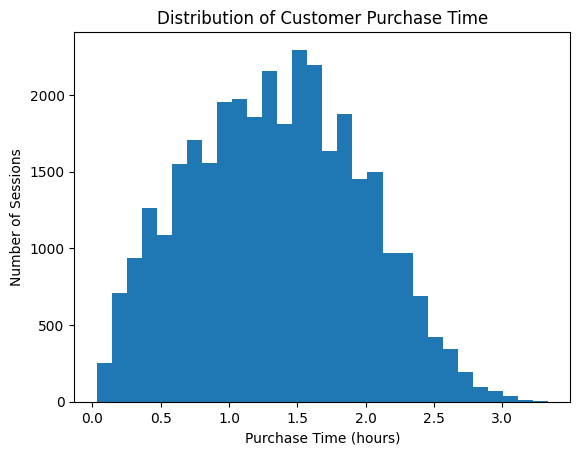

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(session_features["purchase_time_hours"], bins=30)
plt.xlabel("Purchase Time (hours)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Customer Purchase Time")
plt.show()


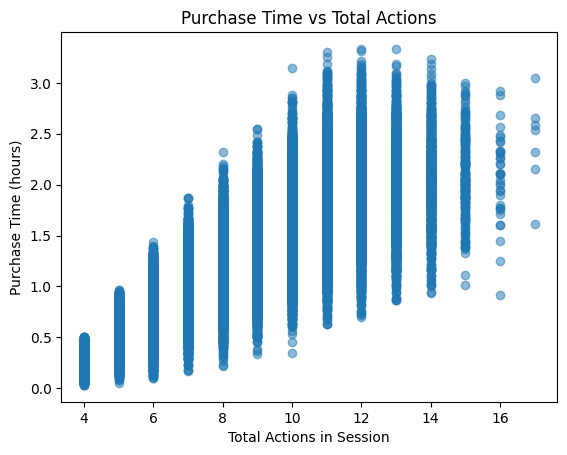

In [13]:
plt.figure()
plt.scatter(
    session_features["total_events"],
    session_features["purchase_time_hours"],
    alpha=0.5
)
plt.xlabel("Total Actions in Session")
plt.ylabel("Purchase Time (hours)")
plt.title("Purchase Time vs Total Actions")
plt.show()


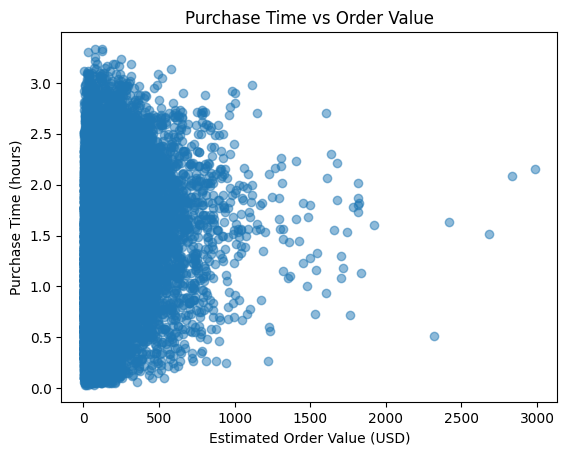

In [14]:
plt.figure()
plt.scatter(
    session_features["total_amount_usd"],
    session_features["purchase_time_hours"],
    alpha=0.5
)
plt.xlabel("Estimated Order Value (USD)")
plt.ylabel("Purchase Time (hours)")
plt.title("Purchase Time vs Order Value")
plt.show()


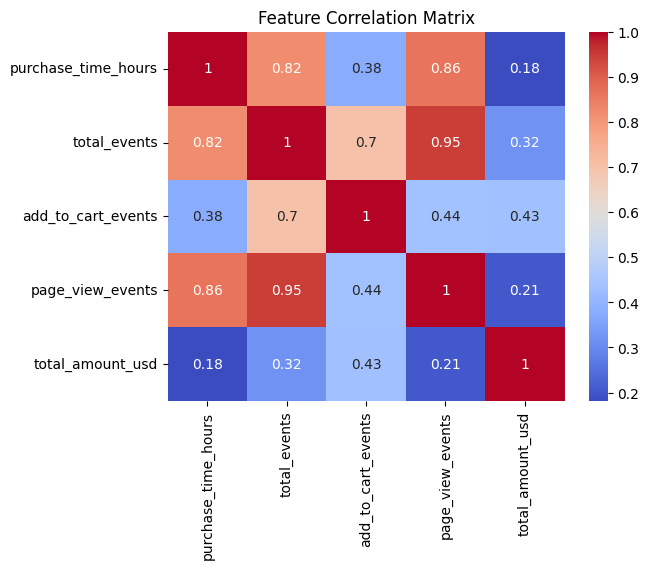

In [15]:
import seaborn as sns

corr = session_features[
    ["purchase_time_hours",
     "total_events",
     "add_to_cart_events",
     "page_view_events",
     "total_amount_usd"]
].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


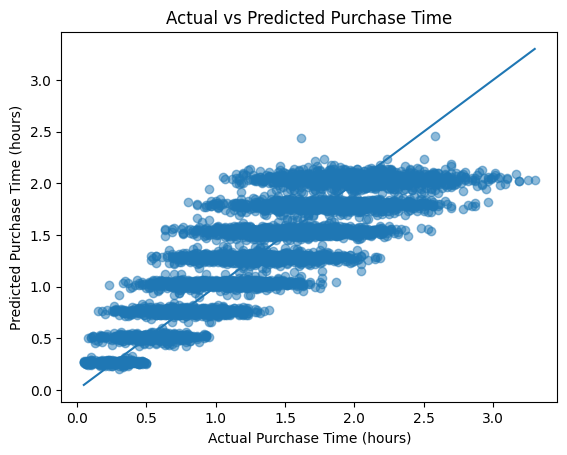

In [18]:
plt.figure()
plt.scatter(y_test_original, y_pred_xgb, alpha=0.5)
plt.xlabel("Actual Purchase Time (hours)")
plt.ylabel("Predicted Purchase Time (hours)")
plt.title("Actual vs Predicted Purchase Time")
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()]
)
plt.show()